# MarBERTv2 Fine-Tuning for Arabic Dialect Sentiment Classification
**Model:** `UBC-NLP/MARBERTv2`  
**Task:** Binary Sentiment Classification (positive / negative)  
**Framework:** PyTorch + HuggingFace Transformers  
**Strategy:** Staged fine-tuning with layer freezing

## Cell 1 — Install & Import Dependencies

In [2]:
# Install required packages (run once)
# !pip install transformers torch scikit-learn pandas numpy tqdm arabert

import os
import random
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW , Adam, SGD
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# Reproducibility seed
# ─────────────────────────────────────────
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)

# ─────────────────────────────────────────
# Device setup — use GPU if available
# ─────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## Cell 2 — Configuration (Edit These to Change Behavior)

In [3]:
# ─────────────────────────────────────────────────────────────────
# CONFIG — All hyperparameters and settings in one place
# ─────────────────────────────────────────────────────────────────

CONFIG = {
    # Data
    'train_path':      '/content/train.csv',             # ← Change to your train CSV path
    'val_path':        '/content/val.csv',               # ← Change to your validation CSV path
    'test_path':       '/content/test.csv',              # ← Change to your test CSV path
    'text_col':        'clean_text',               # Column to use as model input
    'label_col':       'labels',                 # Column with sentiment labels

    # Model
    'model_name':      'UBC-NLP/MARBERTv2',
    'num_labels':      2,
    'max_length':      128,                     # Max token length (128 covers ~95% of Arabic tweets)

    # Training
    'batch_size':      32,
    'num_epochs':      30,
    'learning_rate':   2e-5,
    'weight_decay':    0.01,
    'warmup_ratio':    0.1,                     # 10% of total steps for LR warmup
    'dropout':         0.1,

    # Data splits
    'val_size':        0.15,                     # 10% validation
    'test_size':       0.15,                     # 10% test

    # Freezing — how many encoder layers to freeze (0 = freeze none beyond embeddings)
    # AraBERT-base has 12 encoder layers (0 through 11)
    # Recommendation: freeze first 4 layers for 7k dataset
    'freeze_embeddings':    True,               # Always freeze embeddings for small datasets
    'num_frozen_layers':    6,                  # Freeze encoder layers 0,1,2,3

    # Early stopping
    'patience':             3,                  # Stop after N epochs with no val improvement
    'min_delta':            0.001,              # Minimum improvement to count

    # Output
    'save_path':            'best_arabert_model.pt',
}

# Label mapping — text → numeric
LABEL2ID = {'negative': 0, 'positive': 1}
ID2LABEL = {0: 'negative', 1: 'positive'}

print("Configuration loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration loaded:
  train_path: /content/train.csv
  val_path: /content/val.csv
  test_path: /content/test.csv
  text_col: clean_text
  label_col: labels
  model_name: UBC-NLP/MARBERTv2
  num_labels: 2
  max_length: 128
  batch_size: 32
  num_epochs: 30
  learning_rate: 2e-05
  weight_decay: 0.01
  warmup_ratio: 0.1
  dropout: 0.1
  val_size: 0.15
  test_size: 0.15
  freeze_embeddings: True
  num_frozen_layers: 6
  patience: 3
  min_delta: 0.001
  save_path: best_arabert_model.pt


## Cell 3 — Load Data


In [4]:
# ─────────────────────────────────────────────────────────────────
# LOAD PRE-SPLIT DATASETS
# ─────────────────────────────────────────────────────────────────

train_df = pd.read_csv(CONFIG['train_path'])
val_df   = pd.read_csv(CONFIG['val_path'])
test_df  = pd.read_csv(CONFIG['test_path'])

train_texts = train_df[CONFIG['text_col']].astype(str).tolist()
val_texts   = val_df[CONFIG['text_col']].astype(str).tolist()
test_texts  = test_df[CONFIG['text_col']].astype(str).tolist()

train_labels = train_df[CONFIG['label_col']].replace(LABEL2ID).astype(int).tolist()
val_labels   = val_df[CONFIG['label_col']].replace(LABEL2ID).astype(int).tolist()
test_labels  = test_df[CONFIG['label_col']].replace(LABEL2ID).astype(int).tolist()

In [5]:
train_df.head()

,clean_text,labels,dialect_id
0,صاي هبلتي,0,0
1,تحالف المنافقين يتهم الحكومة بالكذب يا للمسخرة,0,10
2,جهنم واش راهي تسنا,0,0
3,بنات المسلمين اجمعين اشرف من الشرف و مو بس بنا...,1,11
4,من تزدانها واضحة من سوسة,1,6


## Cell 4 — Upload Pre-Split Train / Validation / Test Data


In [6]:
# ─────────────────────────────────────────────────────────────────
# USE UPLOADED SPLITS
# No train/validation/test splitting is done here.
# The code only reads your already split datasets.
# ─────────────────────────────────────────────────────────────────

train_texts  = train_df[CONFIG['text_col']].tolist()
train_labels = train_df[CONFIG['label_col']]

val_texts    = val_df[CONFIG['text_col']].tolist()
val_labels   = val_df[CONFIG['label_col']]

test_texts   = test_df[CONFIG['text_col']].tolist()
test_labels  = test_df[CONFIG['label_col']]

print(f"Train samples:      {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Test samples:       {len(test_texts)}")


Train samples:      5068
Validation samples: 1086
Test samples:       1086


## Cell 5 — Tokenizer & Custom Dataset

In [7]:
# ─────────────────────────────────────────────────────────────────
# TOKENIZER
# AraBERT's tokenizer handles Arabic normalization internally:
# - Removes tatweel (ـ)
# - Normalizes hamza forms
# - Applies farasa segmentation (arabertv02)
# You should NOT manually preprocess the text beyond what
# is already done in dl_text
# ─────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f"Tokenizer loaded: {CONFIG['model_name']}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

# Quick sanity check on an Arabic sample
sample = "المنتج رائع جداً وأنصح به"
tokens = tokenizer(sample, return_tensors='pt')
print(f"\nSample: {sample}")
print(f"Token IDs: {tokens['input_ids']}")
print(f"Decoded: {tokenizer.decode(tokens['input_ids'][0])}")


# ─────────────────────────────────────────────────────────────────
# CUSTOM PYTORCH DATASET
# ─────────────────────────────────────────────────────────────────

class ArabicSentimentDataset(Dataset):
    """
    PyTorch Dataset for Arabic sentiment classification.
    Tokenizes text on-the-fly in __getitem__.
    """

    def __init__(self, texts, labels, tokenizer, max_length):
        """
        Args:
            texts      : list of Arabic strings (from dl_text column)
            labels     : list of int (0=negative, 1=positive)
            tokenizer  : HuggingFace tokenizer
            max_length : max number of tokens (128 recommended)
        """
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize: add [CLS] and [SEP], pad/truncate to max_length
        encoding = self.tokenizer(
            text,
            max_length      = self.max_length,
            padding         = 'max_length',   # Pad shorter sequences
            truncation      = True,            # Truncate longer sequences
            return_tensors  = 'pt'             # Return PyTorch tensors
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),       # Shape: [max_length]
            'attention_mask': encoding['attention_mask'].squeeze(0),  # Shape: [max_length]
            'token_type_ids': encoding.get('token_type_ids',
                              torch.zeros(self.max_length, dtype=torch.long)).squeeze(0),
            'labels':         torch.tensor(label, dtype=torch.long)
        }


# ─────────────────────────────────────────────────────────────────
# CREATE DATASETS AND DATALOADERS
# ─────────────────────────────────────────────────────────────────

train_dataset = ArabicSentimentDataset(train_texts, train_labels, tokenizer, CONFIG['max_length'])
val_dataset   = ArabicSentimentDataset(val_texts,   val_labels,   tokenizer, CONFIG['max_length'])
test_dataset  = ArabicSentimentDataset(test_texts,  test_labels,  tokenizer, CONFIG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f"\nDatasets created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# Inspect one batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
for k, v in sample_batch.items():
    print(f"  {k}: {v.shape}")

config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: UBC-NLP/MARBERTv2
Vocab size: 100,000

Sample: المنتج رائع جداً وأنصح به
Token IDs: tensor([[    2, 25288,  5473,  2551, 14069,  2267,     3]])
Decoded: [CLS] المنتج رايع جدا وانصح به [SEP]

Datasets created:
  Train batches: 159
  Val batches:   34
  Test batches:  34

Sample batch shapes:
  input_ids: torch.Size([32, 128])
  attention_mask: torch.Size([32, 128])
  token_type_ids: torch.Size([32, 128])
  labels: torch.Size([32])


## Cell 6 — Load AraBERT Model & Apply Layer Freezing

In [8]:
# ─────────────────────────────────────────────────────────────────
# LOAD ARABERT WITH CLASSIFICATION HEAD
# AutoModelForSequenceClassification adds a [CLS] → Linear(768, 2)
# classification head on top of AraBERT
# ─────────────────────────────────────────────────────────────────

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels         = CONFIG['num_labels'],
    id2label           = ID2LABEL,
    label2id           = LABEL2ID,
    hidden_dropout_prob = CONFIG['dropout'],
    attention_probs_dropout_prob = CONFIG['dropout'],
)

model = model.to(device)
print(f"Model loaded and moved to {device}")


# ─────────────────────────────────────────────────────────────────
# LAYER FREEZING
#
# AraBERT structure:
#   bert.embeddings                  → word/position/token-type embeddings
#   bert.encoder.layer[0]            → first transformer block (syntax)
#   bert.encoder.layer[1]            → second transformer block
#   ...                              → ...
#   bert.encoder.layer[11]           → last transformer block (task-specific)
#   bert.pooler                      → [CLS] projection
#   classifier                       → final linear layer (always trainable)
#
# WHY these choices:
#   Embeddings: Store subword Arabic morphology — stable, not task-specific
#   Layers 0–3: Capture syntax and morphology — already good for Arabic
#   Layers 4–11: Capture semantics — these adapt to sentiment
# ─────────────────────────────────────────────────────────────────

def freeze_arabert_layers(model, freeze_embeddings=True, num_frozen_layers=4):
    """
    Freeze AraBERT layers for staged fine-tuning.

    Args:
        model              : the loaded AraBERT model
        freeze_embeddings  : if True, freeze the embedding layer
        num_frozen_layers  : number of encoder layers to freeze (0 to 12)
                             0 = only freeze embeddings (if freeze_embeddings=True)
                             4 = freeze encoder layers 0,1,2,3
                             12 = freeze all encoder layers (fine-tune head only)
    """
    frozen_params = 0
    trainable_params = 0

    # ── Freeze embedding layer ──────────────────────────────────────
    if freeze_embeddings:
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
        emb_count = sum(p.numel() for p in model.bert.embeddings.parameters())
        print(f"[FROZEN]    bert.embeddings  → {emb_count:>10,} params")
        frozen_params += emb_count
    else:
        emb_count = sum(p.numel() for p in model.bert.embeddings.parameters())
        print(f"[TRAINABLE] bert.embeddings  → {emb_count:>10,} params")
        trainable_params += emb_count

    # ── Freeze/unfreeze encoder layers ──────────────────────────────
    total_layers = len(model.bert.encoder.layer)
    print(f"\nTotal encoder layers: {total_layers}")

    for layer_idx, layer in enumerate(model.bert.encoder.layer):
        layer_params = sum(p.numel() for p in layer.parameters())
        if layer_idx < num_frozen_layers:
            for param in layer.parameters():
                param.requires_grad = False
            print(f"[FROZEN]    bert.encoder.layer[{layer_idx}] → {layer_params:>10,} params  (syntax/morphology)")
            frozen_params += layer_params
        else:
            for param in layer.parameters():
                param.requires_grad = True
            print(f"[TRAINABLE] bert.encoder.layer[{layer_idx}] → {layer_params:>10,} params  (semantics/task)")
            trainable_params += layer_params

    # ── Pooler is always trainable ───────────────────────────────────
    for param in model.bert.pooler.parameters():
        param.requires_grad = True
    pooler_count = sum(p.numel() for p in model.bert.pooler.parameters())
    print(f"[TRAINABLE] bert.pooler        → {pooler_count:>10,} params")
    trainable_params += pooler_count

    # ── Classifier head is always trainable ─────────────────────────
    for param in model.classifier.parameters():
        param.requires_grad = True
    cls_count = sum(p.numel() for p in model.classifier.parameters())
    print(f"[TRAINABLE] classifier         → {cls_count:>10,} params")
    trainable_params += cls_count

    total = frozen_params + trainable_params
    print(f"\n{'─'*55}")
    print(f"Frozen params:    {frozen_params:>10,} ({100*frozen_params/total:.1f}%)")
    print(f"Trainable params: {trainable_params:>10,} ({100*trainable_params/total:.1f}%)")
    print(f"Total params:     {total:>10,}")
    print(f"{'─'*55}")


# Apply initial freezing
print("\n=== INITIAL FREEZE (Stage 1) ===")
freeze_arabert_layers(
    model,
    freeze_embeddings  = CONFIG['freeze_embeddings'],
    num_frozen_layers  = CONFIG['num_frozen_layers']
)

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect ide

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

Model loaded and moved to cuda

=== INITIAL FREEZE (Stage 1) ===
[FROZEN]    bert.embeddings  → 77,196,288 params

Total encoder layers: 12
[FROZEN]    bert.encoder.layer[0] →  7,087,872 params  (syntax/morphology)
[FROZEN]    bert.encoder.layer[1] →  7,087,872 params  (syntax/morphology)
[FROZEN]    bert.encoder.layer[2] →  7,087,872 params  (syntax/morphology)
[FROZEN]    bert.encoder.layer[3] →  7,087,872 params  (syntax/morphology)
[FROZEN]    bert.encoder.layer[4] →  7,087,872 params  (syntax/morphology)
[FROZEN]    bert.encoder.layer[5] →  7,087,872 params  (syntax/morphology)
[TRAINABLE] bert.encoder.layer[6] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[7] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[8] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[9] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[10] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[11] →  7,087,872 p

## Cell 7 — Optimizer, Scheduler & Early Stopping

In [9]:
# ─────────────────────────────────────────────────────────────────
# OPTIMIZER — Adam with weight decay
# Only pass parameters that require gradients (trainable ones)
# ─────────────────────────────────────────────────────────────────

# Separate out weight decay: don't apply it to bias or LayerNorm weights
no_decay = ['bias', 'LayerNorm.weight', 'layer_norm.weight']

optimizer_grouped_params = [
    {
        'params': [p for n, p in model.named_parameters()
                   if p.requires_grad and not any(nd in n for nd in no_decay)],
        'weight_decay': CONFIG['weight_decay']
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if p.requires_grad and any(nd in n for nd in no_decay)],
        'weight_decay': 0.0   # No decay for bias / LayerNorm
    }
]

optimizer = Adam(optimizer_grouped_params, lr=CONFIG['learning_rate'], eps=1e-8)

# ─────────────────────────────────────────────────────────────────
# LEARNING RATE SCHEDULER — linear warmup then linear decay
# Warmup stabilizes training in the first N steps, then decays LR
# ─────────────────────────────────────────────────────────────────

total_steps   = len(train_loader) * CONFIG['num_epochs']
warmup_steps  = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps:         {warmup_steps}")

# ─────────────────────────────────────────────────────────────────
# LOSS FUNCTION — Cross Entropy (standard for classification)
# ─────────────────────────────────────────────────────────────────
loss_fn = nn.CrossEntropyLoss()


# ─────────────────────────────────────────────────────────────────
# EARLY STOPPING
# Monitors validation F1 — stops if no improvement for N epochs
# ─────────────────────────────────────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001, mode='max'):
        """
        Args:
            patience  : epochs to wait with no improvement
            min_delta : minimum change to count as improvement
            mode      : 'max' for F1/accuracy, 'min' for loss
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self.mode == 'max' and score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"   EarlyStopping: no improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True
        elif self.mode == 'min' and score > self.best_score - self.min_delta:
            self.counter += 1
            print(f"   EarlyStopping: no improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0

early_stopper = EarlyStopping(
    patience  = CONFIG['patience'],
    min_delta = CONFIG['min_delta'],
    mode      = 'max'   # Tracking F1 — higher is better
)

print("Optimizer, scheduler, and early stopping initialized.")

Total training steps: 4770
Warmup steps:         477
Optimizer, scheduler, and early stopping initialized.


## Cell 8 — Training & Validation Loop

In [10]:
# ─────────────────────────────────────────────────────────────────
# METRICS HELPER
# ─────────────────────────────────────────────────────────────────

def compute_metrics(all_preds, all_labels):
    """Compute accuracy, precision, recall, F1 (macro)."""
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


# ─────────────────────────────────────────────────────────────────
# ONE EPOCH — TRAINING
# ─────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()   # Enable dropout + batch norm training mode
    total_loss = 0.0
    all_preds, all_labels = [], []

    loop = tqdm(loader, desc='Training', leave=False)
    for batch in loop:
        # Move everything to device
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids
        )
        logits = outputs.logits          # Shape: [batch_size, num_labels]

        # Loss
        loss = loss_fn(logits, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights and scheduler
        optimizer.step()
        scheduler.step()

        # Collect predictions
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        total_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(loader)
    metrics  = compute_metrics(all_preds, all_labels)
    return avg_loss, metrics


# ─────────────────────────────────────────────────────────────────
# ONE EPOCH — VALIDATION (no gradient computation)
# ─────────────────────────────────────────────────────────────────

def evaluate(model, loader, loss_fn, device):
    model.eval()   # Disable dropout
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():   # No gradient tracking during evaluation
        loop = tqdm(loader, desc='Evaluating', leave=False)
        for batch in loop:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids
            )
            logits = outputs.logits
            loss   = loss_fn(logits, labels)

            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    metrics  = compute_metrics(all_preds, all_labels)
    return avg_loss, metrics


# ─────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────

best_val_f1    = 0.0
history        = []

print(f"\nStarting training for up to {CONFIG['num_epochs']} epochs...")
print(f"Early stopping patience: {CONFIG['patience']} epochs\n")

for epoch in range(1, CONFIG['num_epochs'] + 1):
    print(f"Epoch {epoch}/{CONFIG['num_epochs']}")
    print('─' * 50)

    # Train
    train_loss, train_metrics = train_one_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device
    )

    # Validate
    val_loss, val_metrics = evaluate(model, val_loader, loss_fn, device)

    # Log
    row = {
        'epoch':      epoch,
        'train_loss': train_loss,
        'val_loss':   val_loss,
        **{f'train_{k}': v for k, v in train_metrics.items()},
        **{f'val_{k}':   v for k, v in val_metrics.items()},
    }
    history.append(row)

    print(f"  Train → Loss: {train_loss:.4f}  Acc: {train_metrics['accuracy']:.4f}  F1: {train_metrics['f1']:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}  Acc: {val_metrics['accuracy']:.4f}  F1: {val_metrics['f1']:.4f}")
    print(f"          Precision: {val_metrics['precision']:.4f}  Recall: {val_metrics['recall']:.4f}")

    # Save best model based on validation F1
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state':  optimizer.state_dict(),
            'val_f1':           best_val_f1,
            'config':           CONFIG,
        }, CONFIG['save_path'])
        print(f"  ✓ Best model saved! Val F1: {best_val_f1:.4f}")

    # Early stopping
    early_stopper(val_metrics['f1'])
    if early_stopper.stop:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

    print()

print(f"\nTraining complete! Best validation F1: {best_val_f1:.4f}")
print(f"Best model saved to: {CONFIG['save_path']}")

history_stage1 = pd.DataFrame(history).copy()



Starting training for up to 30 epochs...
Early stopping patience: 3 epochs

Epoch 1/30
──────────────────────────────────────────────────



Training: 100%|██████████| 159/159 [00:17<00:00, 10.53it/s, loss=0.6365]


  Train → Loss: 0.6779  Acc: 0.5921  F1: 0.5891
  Val   → Loss: 0.6175  Acc: 0.8306  F1: 0.8298
          Precision: 0.8339  Recall: 0.8295
  ✓ Best model saved! Val F1: 0.8298

Epoch 2/30
──────────────────────────────────────────────────


  Train → Loss: 0.4042  Acc: 0.8792  F1: 0.8792
  Val   → Loss: 0.2285  Acc: 0.9144  F1: 0.9144
          Precision: 0.9148  Recall: 0.9148
  ✓ Best model saved! Val F1: 0.9144

Epoch 3/30
──────────────────────────────────────────────────


  Train → Loss: 0.2399  Acc: 0.9096  F1: 0.9096
  Val   → Loss: 0.2034  Acc: 0.9254  F1: 0.9254
          Precision: 0.9255  Recall: 0.9253
  ✓ Best model saved! Val F1: 0.9254

Epoch 4/30
──────────────────────────────────────────────────


  Train → Loss: 0.2226  Acc: 0.9159  F1: 0.9159
  Val   → Loss: 0.1994  Acc: 0.9263  F1: 0.9263
          Precision: 0.9263  Recall: 0.9265
  ✓ Best model saved! Val F1: 0.9263
   EarlyStopping: no improvement (1/3)

Epoch 5/30
──────────────────────────────────────────────────


  Train → Loss: 0.2007  Acc: 0.9278  F1: 0.9278
  Val   → Loss: 0.2028  Acc: 0.9254  F1: 0.9253
          Precision: 0.9263  Recall: 0.9250
   EarlyStopping: no improvement (2/3)

Epoch 6/30
──────────────────────────────────────────────────


  Train → Loss: 0.1911  Acc: 0.9286  F1: 0.9286
  Val   → Loss: 0.1992  Acc: 0.9199  F1: 0.9199
          Precision: 0.9201  Recall: 0.9202
   EarlyStopping: no improvement (3/3)

Early stopping triggered at epoch 6.

Training complete! Best validation F1: 0.9263
Best model saved to: best_arabert_model.pt


## Stage 1 / Stage 2 Plot Helpers

In [11]:

# ─────────────────────────────────────────────────────────────────
# STAGE PLOTTING HELPERS
# ─────────────────────────────────────────────────────────────────

def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids
            )
            logits = outputs.logits
            preds  = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels


def plot_stage_results(stage_title, checkpoint_path, history_df, loader=test_loader):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded {stage_title} checkpoint from epoch {checkpoint['epoch']} with Val F1: {checkpoint['val_f1']:.4f}")

    all_preds, all_labels = collect_predictions(model, loader, device)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(ID2LABEL.values())
    ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'{stage_title} — Confusion Matrix')

    # Loss curve
    axes[1].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o')
    axes[1].plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss',   marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title(f'{stage_title} — Learning Curve (Loss)')
    axes[1].legend()
    axes[1].grid(True)

    # F1 curve
    axes[2].plot(history_df['epoch'], history_df['train_f1'], label='Train F1', marker='o')
    axes[2].plot(history_df['epoch'], history_df['val_f1'],   label='Val F1',   marker='o')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score (Macro)')
    axes[2].set_title(f'{stage_title} — Tuning Curve (F1)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


## Stage 1 — Freeze
Confusion matrix + learning/tuning curves for the frozen stage.

Loaded Stage 1 (Freeze) checkpoint from epoch 4 with Val F1: 0.9263


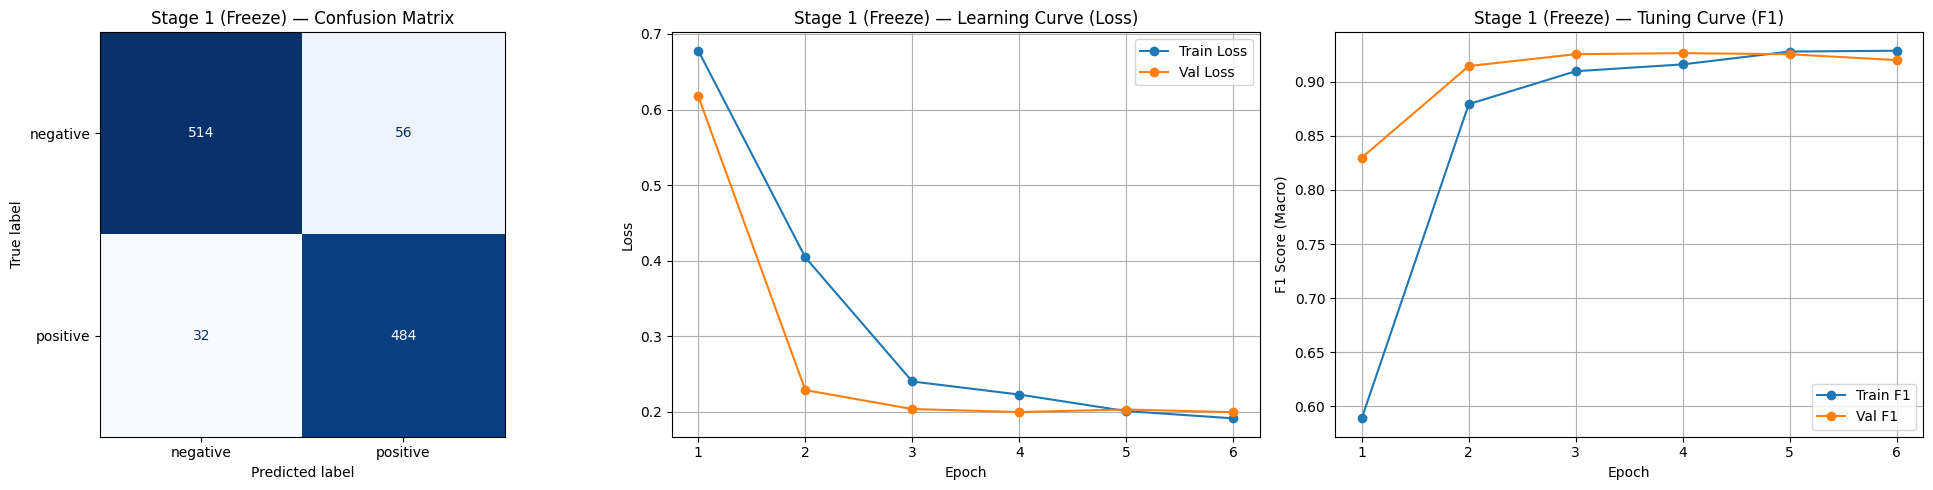

In [12]:
plot_stage_results('Stage 1 (Freeze)', CONFIG['save_path'], history_stage1, loader=test_loader)

## Cell 9 — Stage 2: Unfreeze for Continued Fine-Tuning (Optional)
Run this cell if you want to do staged fine-tuning after Stage 1 converges.

In [13]:
# ─────────────────────────────────────────────────────────────────
# STAGE 2: UNFREEZE AND CONTINUE TRAINING
#
# After Stage 1, the classification head has learned from the
# frozen AraBERT representations. Now we unfreeze the lower layers
# and fine-tune the entire model with a MUCH lower learning rate
# to avoid destroying the pretrained weights.
#
# Typical approach:
#   Stage 1: LR=2e-5, freeze layers 0–3   (3–5 epochs)
#   Stage 2: LR=5e-6, unfreeze all         (2–3 more epochs)
# ─────────────────────────────────────────────────────────────────

# Load best checkpoint from Stage 1
checkpoint = torch.load(CONFIG['save_path'], map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best Stage 1 checkpoint from epoch {checkpoint['epoch']} (Val F1: {checkpoint['val_f1']:.4f})")

# Unfreeze all layers (pass 0 frozen layers)
print("\n=== UNFREEZING FOR STAGE 2 ===")
freeze_arabert_layers(
    model,
    freeze_embeddings  = False,   # Unfreeze embeddings too
    num_frozen_layers  = 0        # Unfreeze all encoder layers
)

# New optimizer with MUCH lower learning rate
STAGE2_LR = 5e-6

optimizer_s2 = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr           = STAGE2_LR,
    weight_decay = CONFIG['weight_decay'],
    eps          = 1e-8
)

STAGE2_EPOCHS = 3
total_steps_s2 = len(train_loader) * STAGE2_EPOCHS
warmup_steps_s2 = int(total_steps_s2 * 0.05)  # Shorter warmup for fine-tuning

scheduler_s2 = get_linear_schedule_with_warmup(
    optimizer_s2,
    num_warmup_steps   = warmup_steps_s2,
    num_training_steps = total_steps_s2
)

early_stopper_s2 = EarlyStopping(patience=2, min_delta=0.001, mode='max')

best_val_f1_s2 = checkpoint['val_f1']   # Start from Stage 1 best
history_stage2 = []

print(f"\nStage 2 training: LR={STAGE2_LR}, up to {STAGE2_EPOCHS} epochs\n")

for epoch in range(1, STAGE2_EPOCHS + 1):
    print(f"Stage 2 — Epoch {epoch}/{STAGE2_EPOCHS}")
    print('─' * 50)

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, optimizer_s2, scheduler_s2, loss_fn, device
    )
    val_loss, val_metrics = evaluate(model, val_loader, loss_fn, device)

    print(f"  Train → Loss: {train_loss:.4f}  F1: {train_metrics['f1']:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}  F1: {val_metrics['f1']:.4f}")
    history_stage2.append({
        'epoch':      epoch,
        'train_loss': train_loss,
        'val_loss':   val_loss,
        **{f'train_{k}': v for k, v in train_metrics.items()},
        **{f'val_{k}':   v for k, v in val_metrics.items()},
    })


    if val_metrics['f1'] > best_val_f1_s2:
        best_val_f1_s2 = val_metrics['f1']
        torch.save({
            'epoch':            epoch,
            'stage':            2,
            'model_state_dict': model.state_dict(),
            'val_f1':           best_val_f1_s2,
            'config':           CONFIG,
        }, 'best_arabert_stage2.pt')
        print(f"  ✓ Stage 2 best saved! Val F1: {best_val_f1_s2:.4f}")

    early_stopper_s2(val_metrics['f1'])
    if early_stopper_s2.stop:
        print(f"Stage 2 early stopping at epoch {epoch}.")
        break

print(f"\nStage 2 complete! Best Val F1: {best_val_f1_s2:.4f}")

history_stage2 = pd.DataFrame(history_stage2).copy()
stage2_ckpt_path = 'best_arabert_stage2.pt' if os.path.exists('best_arabert_stage2.pt') else CONFIG['save_path']


Loaded best Stage 1 checkpoint from epoch 4 (Val F1: 0.9263)

=== UNFREEZING FOR STAGE 2 ===
[TRAINABLE] bert.embeddings  → 77,196,288 params

Total encoder layers: 12
[TRAINABLE] bert.encoder.layer[0] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[1] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[2] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[3] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[4] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[5] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[6] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[7] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[8] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[9] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[10] →  7,087,872 params  (semantics/task)
[TRAINABLE] bert.encoder.layer[11] →  7

  Train → Loss: 0.1880  F1: 0.9303
  Val   → Loss: 0.1980  F1: 0.9245
Stage 2 — Epoch 2/3
──────────────────────────────────────────────────


  Train → Loss: 0.1459  F1: 0.9493
  Val   → Loss: 0.2067  F1: 0.9290
  ✓ Stage 2 best saved! Val F1: 0.9290
Stage 2 — Epoch 3/3
──────────────────────────────────────────────────


  Train → Loss: 0.1206  F1: 0.9590
  Val   → Loss: 0.2027  F1: 0.9281
   EarlyStopping: no improvement (1/2)

Stage 2 complete! Best Val F1: 0.9290


## Stage 2 — Unfreeze
Confusion matrix + learning/tuning curves for the unfrozen stage.

Loaded Stage 2 (Unfreeze) checkpoint from epoch 2 with Val F1: 0.9290


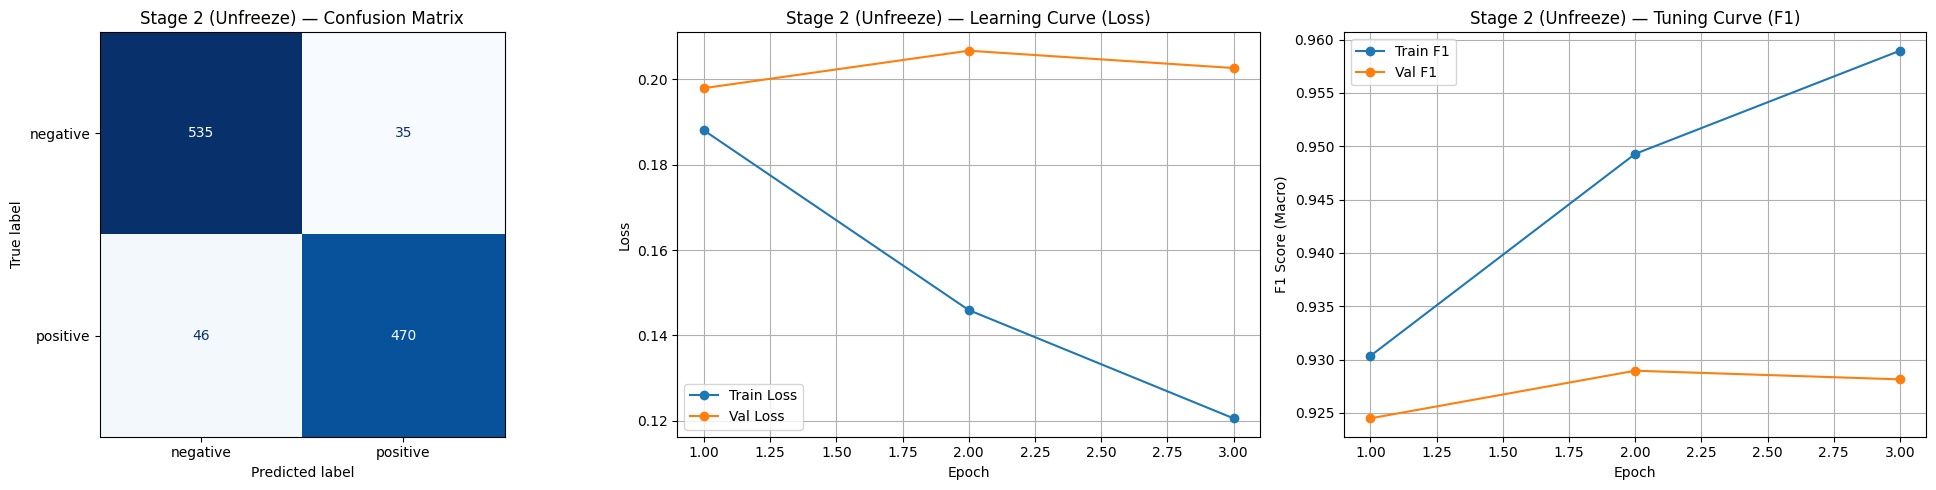

In [14]:
plot_stage_results('Stage 2 (Unfreeze)', stage2_ckpt_path, history_stage2, loader=test_loader)

## Cell 13 — Inference on New Text

In [15]:
# ─────────────────────────────────────────────────────────────────
# INFERENCE FUNCTION — Use on new Arabic text at any time
# ─────────────────────────────────────────────────────────────────

def predict_sentiment(texts, model, tokenizer, device, max_length=128):
    """
    Run inference on a list of Arabic strings.

    Args:
        texts      : list of Arabic strings (pre-cleaned, like dl_text)
        model      : fine-tuned AraBERT model
        tokenizer  : AraBERT tokenizer
        device     : torch.device
        max_length : tokenization max length

    Returns:
        DataFrame with text, label, confidence
    """
    model.eval()
    results = []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer(
                str(text),
                max_length     = max_length,
                padding        = 'max_length',
                truncation     = True,
                return_tensors = 'pt'
            )
            input_ids      = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            token_type_ids = encoding.get('token_type_ids',
                             torch.zeros_like(input_ids)).to(device)

            output = model(input_ids=input_ids, attention_mask=attention_mask,
                           token_type_ids=token_type_ids)
            probs   = torch.softmax(output.logits, dim=-1).squeeze(0).cpu().numpy()
            pred_id = probs.argmax()

            results.append({
                'text':           text,
                'predicted':      ID2LABEL[pred_id],
                'confidence':     float(probs[pred_id]),
                'prob_negative':  float(probs[0]),
                'prob_positive':  float(probs[1]),
            })

    return pd.DataFrame(results)


# Example usage
sample_texts = [
    "المنتج ممتاز وجودته عالية جداً",          # Positive (MSA)
    "الخدمة كانت سيئة وما عجبتني",              # Negative (Gulf dialect)
    "عادي مش عاجبني ولا بكرهه",                # Ambiguous (Levantine)
    "والله اشتريته وماندمت عليه",               # Positive (Gulf)
]

preds = predict_sentiment(sample_texts, model, tokenizer, device)
print(preds.to_string(index=False))

                          text predicted  confidence  prob_negative  prob_positive
المنتج ممتاز وجودته عالية جداً  positive    0.994112       0.005888       0.994112
   الخدمة كانت سيئة وما عجبتني  negative    0.784643       0.784643       0.215357
      عادي مش عاجبني ولا بكرهه  negative    0.921562       0.921562       0.078438
    والله اشتريته وماندمت عليه  positive    0.985592       0.014408       0.985592


## Cell 13 — ROC CURVES FOR ALL STAGES


Loaded checkpoint: best_arabert_model.pt
  Saved at epoch : 4
  Val F1         : 0.9263

FINAL TEST SET RESULTS
  Accuracy        : 0.9190
  Macro F1        : 0.9189
  Macro Precision : 0.9188
  Macro Recall    : 0.9199

── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

    negative     0.9414    0.9018    0.9211       570
    positive     0.8963    0.9380    0.9167       516

    accuracy                         0.9190      1086
   macro avg     0.9188    0.9199    0.9189      1086
weighted avg     0.9200    0.9190    0.9190      1086



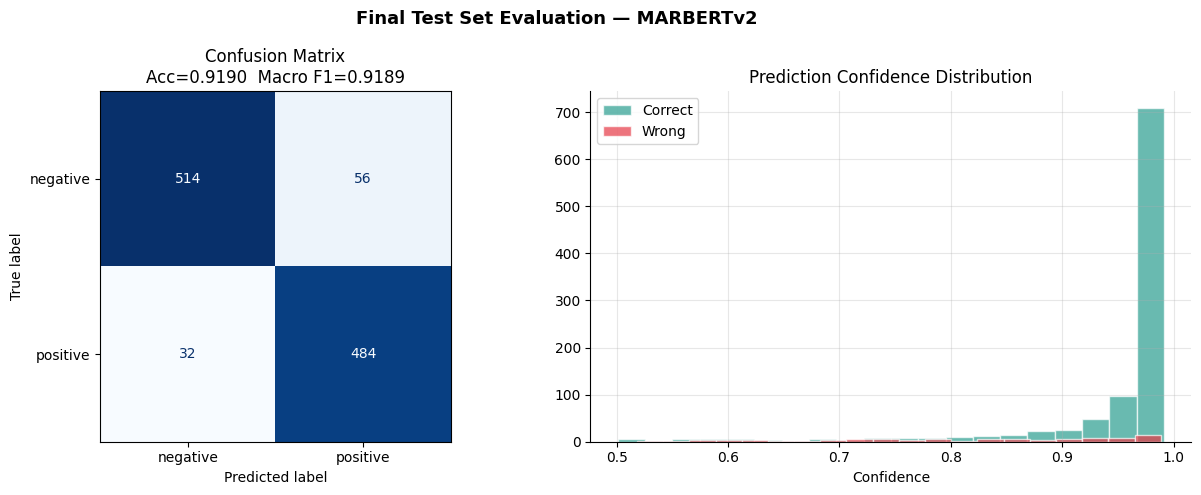

Saved → test_evaluation.png


In [18]:
# ─────────────────────────────────────────────────────────────────
# FINAL TEST SET EVALUATION
# Loads best checkpoint → evaluates on test_loader → full report
# ─────────────────────────────────────────────────────────────────

# Determine which checkpoint to load (Stage 2 if it exists, else Stage 1)
best_ckpt = stage2_ckpt_path if 'stage1_ckpt_path' in dir() and os.path.exists(stage1_ckpt_path) \
            else CONFIG['save_path']

checkpoint = torch.load(best_ckpt, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded checkpoint: {best_ckpt}')
print(f'  Saved at epoch : {checkpoint["epoch"]}')
print(f'  Val F1         : {checkpoint["val_f1"]:.4f}')

# ── Run test evaluation ───────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        logits = outputs.logits
        probs  = torch.softmax(logits, dim=-1)

        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ── Metrics ───────────────────────────────────────────────────────
test_acc = accuracy_score(all_labels, all_preds)
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0)

print()
print('=' * 55)
print('FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy        : {test_acc:.4f}')
print(f'  Macro F1        : {test_f1:.4f}')
print(f'  Macro Precision : {test_prec:.4f}')
print(f'  Macro Recall    : {test_rec:.4f}')
print()
print('── Classification Report ──────────────────────────────────')
print(classification_report(all_labels, all_preds,
      target_names=list(ID2LABEL.values()), digits=4))

# ── Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Final Test Set Evaluation — MARBERTv2', fontsize=13, fontweight='bold')

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=list(ID2LABEL.values())) \
    .plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\nAcc={test_acc:.4f}  Macro F1={test_f1:.4f}')

# Confidence distribution: correct vs wrong
import numpy as np
all_probs_np  = np.array(all_probs)
all_preds_np  = np.array(all_preds)
all_labels_np = np.array(all_labels)
confidence    = all_probs_np.max(axis=1)
correct_mask  = all_preds_np == all_labels_np

axes[1].hist(confidence[correct_mask],  bins=20, alpha=0.7,
             color='#2a9d8f', label='Correct', edgecolor='white')
axes[1].hist(confidence[~correct_mask], bins=20, alpha=0.7,
             color='#e63946', label='Wrong',   edgecolor='white')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Confidence'); axes[1].legend()
axes[1].grid(alpha=0.3); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → test_evaluation.png')


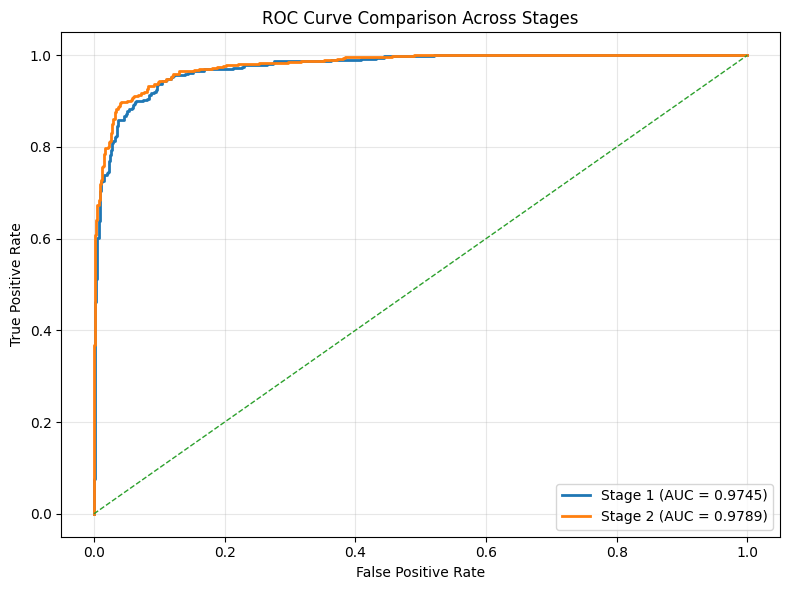

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 14: ROC CURVES FOR ALL STAGES
# ─────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import os

def get_stage_probs_and_labels(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            probs = torch.softmax(outputs.logits, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_probs


plt.figure(figsize=(8, 6))

# -------------------------
# Stage 1
# -------------------------
if os.path.exists(CONFIG['save_path']):
    ckpt1 = torch.load(CONFIG['save_path'], map_location=device)
    model.load_state_dict(ckpt1['model_state_dict'])

    y_true_1, y_prob_1 = get_stage_probs_and_labels(model, test_loader, device)
    fpr1, tpr1, _ = roc_curve(y_true_1, y_prob_1)
    auc1 = auc(fpr1, tpr1)

    plt.plot(fpr1, tpr1, linewidth=2, label=f'Stage 1 (AUC = {auc1:.4f})')

# -------------------------
# Stage 2
# -------------------------
if 'stage2_ckpt_path' in globals() and os.path.exists(stage2_ckpt_path):
    ckpt2 = torch.load(stage2_ckpt_path, map_location=device)
    model.load_state_dict(ckpt2['model_state_dict'])

    y_true_2, y_prob_2 = get_stage_probs_and_labels(model, test_loader, device)
    fpr2, tpr2, _ = roc_curve(y_true_2, y_prob_2)
    auc2 = auc(fpr2, tpr2)

    plt.plot(fpr2, tpr2, linewidth=2, label=f'Stage 2 (AUC = {auc2:.4f})')

# -------------------------
# Stage 3
# -------------------------
if 'stage3_ckpt_path' in globals() and os.path.exists(stage3_ckpt_path):
    ckpt3 = torch.load(stage3_ckpt_path, map_location=device)
    model.load_state_dict(ckpt3['model_state_dict'])

    y_true_3, y_prob_3 = get_stage_probs_and_labels(model, test_loader, device)
    fpr3, tpr3, _ = roc_curve(y_true_3, y_prob_3)
    auc3 = auc(fpr3, tpr3)

    plt.plot(fpr3, tpr3, linewidth=2, label=f'Stage 3 (AUC = {auc3:.4f})')

# Diagonal reference
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Stages')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()